In [211]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns 
import statsmodels.formula.api as smf
import plotly.express as px


In [212]:
walmart = pd.read_csv("STORE_STATUS_PUBLIC_VIEW_3007829193429392206.csv")

walmart.head()

,OBJECTID,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,GlobalID,x,y
0,51077,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,29e01211-412e-47e1-85e9-a4162a9680ca,-1.048062e+07,4.346304e+06
1,51078,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,2e5c7c63-3469-4572-9713-e43b3554c329,-1.036820e+07,4.337694e+06
2,51079,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,42a1faa5-f7aa-4b66-bd07-694501e68678,-9.290317e+06,4.062122e+06
3,51080,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,5ae6449c-7a76-4bb8-a574-fa89ad1c9dc5,-1.052109e+07,4.325893e+06
4,51081,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,b195cb36-dc6c-481e-9149-5f07f3aa1d86,-1.029004e+07,4.178649e+06


lets try to clean it up a bit ??

In [213]:
walmart.shape

(5209, 14)

In [214]:
walmart.isna()

,OBJECTID,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,GlobalID,x,y
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5204,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5205,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5206,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5207,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [215]:
walmart.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5204    False
5205    False
5206    False
5207    False
5208    False
Length: 5209, dtype: bool

In [216]:
walmart.value_counts()

OBJECTID  businessUnit_name   businessUnit_number  Description                 Type       Address                City            County     State  Postal Code  Operation Status  GlobalID                              x              y           
51077     ROGERS, AR          1                    WM Supercenter              Retail     2110 W WALNUT ST       ROGERS          BENTON     AR     72756-3246   Open              29e01211-412e-47e1-85e9-a4162a9680ca  -1.048062e+07  4.346304e+06    1
51078     HARRISON AR         2                    WM Supercenter              Retail     161 N WALMART DR       HARRISON        BOONE      AR     72601-1960   Open              2e5c7c63-3469-4572-9713-e43b3554c329  -1.036820e+07  4.337694e+06    1
51079     COMMERCE GA         3                    WM Supercenter              Retail     30983 HIGHWAY 441 S    COMMERCE        JACKSON    GA     30529-6655   Open              42a1faa5-f7aa-4b66-bd07-694501e68678  -9.290317e+06  4.062122e+06    1
51080    

In [217]:
print(walmart["State"].value_counts().head(50))

State
TX    590
FL    386
CA    303
NC    214
GA    210
IL    177
OH    170
PA    159
MO    156
TN    150
VA    148
AL    143
LA    138
OK    134
AR    129
IN    126
AZ    124
SC    122
MI    117
NY    111
CO    104
KY    101
WI     97
MS     86
KS     82
MN     79
NJ     70
IA     69
WA     64
UT     59
MD     57
NM     53
NV     50
MA     48
NE     47
WV     44
OR     43
CT     32
NH     28
ID     27
PR     26
ME     25
SD     17
ND     17
MT     16
WY     14
HI     11
DE     10
RI      9
AK      9
Name: count, dtype: int64


thats the number of stores or "walmart" by the state 

In [218]:
## lets take a look at what we have here

walmart.head()

## i guess we can filter out the unuseful columns

useful_columns = [
    "businessUnit_name",
    "businessUnit_number",
    "Description",
    "Type",
    "Address",
    "City",
    "County",
    "State",
    "Postal Code",
    "Operation Status",
    "x",
    "y"
]



In [219]:
walmart_clean = walmart[useful_columns]

In [220]:
walmart_clean.head()

## looks better ish 

,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,x,y
0,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,-1.048062e+07,4.346304e+06
1,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,-1.036820e+07,4.337694e+06
2,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,-9.290317e+06,4.062122e+06
3,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,-1.052109e+07,4.325893e+06
4,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,-1.029004e+07,4.178649e+06


## what are we trying to see lets see i guess poke around and guess how many questions we can answer like how many stores in Texas and the answer is 590 so lets get to poking and answer some questions


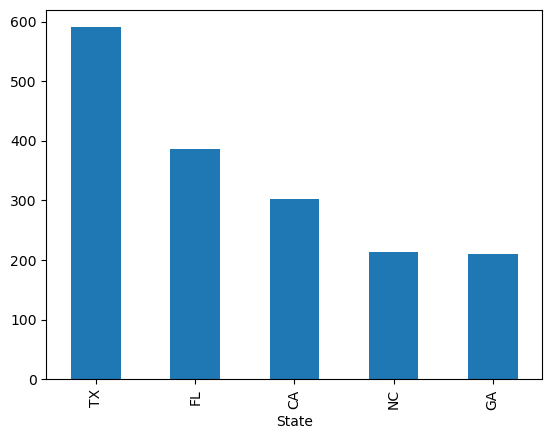

In [221]:
walmart_clean["State"].value_counts().head().plot(kind = "bar"
                                                )
plt.show()

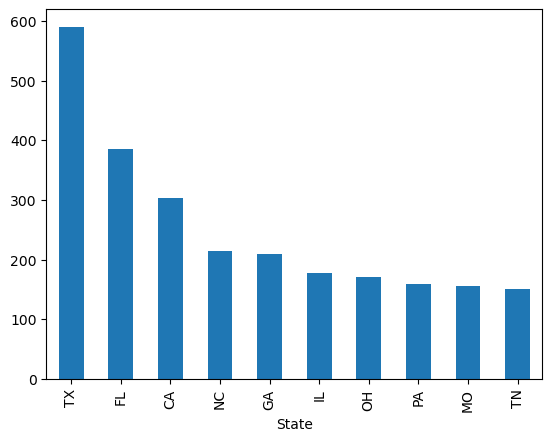

In [222]:
walmart_clean["State"].value_counts().head(10).plot(kind = "bar"
                                                )
plt.show()

# okay so thats the top 10 states in the number of walmarts they have there is also a type column lets make a better chart though

<function matplotlib.pyplot.show(close=None, block=None)>

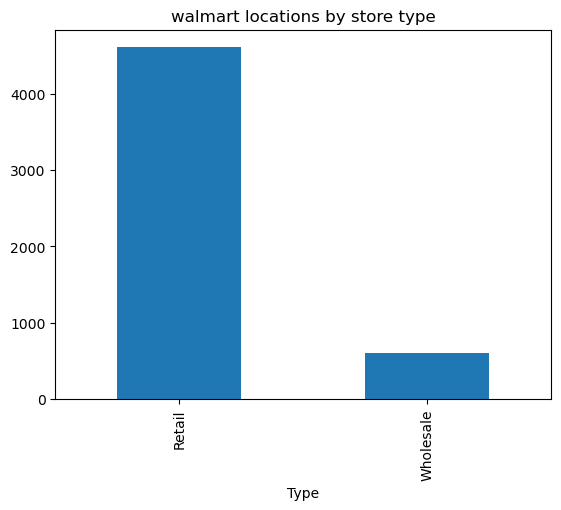

In [223]:
type_counts = walmart_clean["Type"].value_counts()

type_counts.plot(kind= "bar")
plt.title("walmart locations by store type")
plt.show

# okay so there is 2 types retail which is the walmart side of things and sams club would probably be the whole sale side of things thats a big difference  and answer more answers along the way 

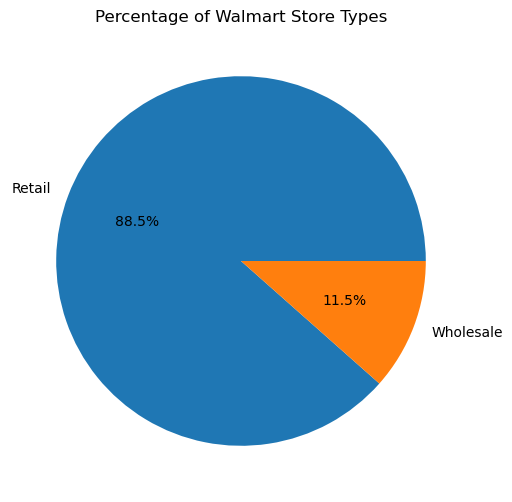

In [224]:
plt.figure(figsize=(6,6))
type_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Walmart Store Types")

plt.show()

# okay so 11.5 percent of the walmart companies business is retail maybe we can find data to see how much money they generate? lets see the entirety of walmart location as a scatter plot

In [225]:
fig = px.scatter_geo(
    walmart_clean,
    lat="y",
    lon="x",
    hover_name="businessUnit_name",
    hover_data=["City", "State", "Type", "Description"],
    scope="usa",
    title="Walmart Store Locations in the United States"
)

fig.show()

# why does it look like that -_- 

# lets see what else can i do do i need more data on how much money they can generate? i dont have money data ?
# ill try to find more data idk im thinking what else i can do with this dataset ??




# okay thought for a while maybe i will compare retail stores across usa vs walmart income but i need income or any type of monetary data? where do i find these

# dug around for a while soooo looks like ill try kaggle? (i need any type of monetary data ) okay kaggle dosent have anything nvm looks like the census on the us data might be good? lets see... 

# loading the dataset

In [226]:
df = pd.read_csv("RSXFS.csv")
df.head()


,observation_date,RSXFS
0,1992-01-01,142419
1,1992-02-01,142584
2,1992-03-01,142120
3,1992-04-01,143659
4,1992-05-01,144239


In [227]:
df.tail()

,observation_date,RSXFS
405,2025-10-01,631346
406,2025-11-01,634477
407,2025-12-01,634830
408,2026-01-01,634233
409,2026-02-01,638224


In [228]:
print(df.columns)


Index(['observation_date', 'RSXFS'], dtype='str')


In [229]:
type(df["observation_date"])

#okay its in pandas.series i might wanna convert to date time  like we did in class?


pandas.Series

In [230]:
print(df["observation_date"].dtype)  ## and its contents are string so yeah defo change it

str


In [231]:
df["observation_date"] = pd.to_datetime(df["observation_date"])
print(df["observation_date"].dtype)


datetime64[us]


In [232]:
df = df.rename(columns={
    "observation_date": "date", "RSXFS": "retail_sales"})  ## chagning the column names to make it easier

# whoops lets check the retail column as well


In [233]:
type(df["retail_sales"])

pandas.Series

In [234]:
df.columns

Index(['date', 'retail_sales'], dtype='str')

In [235]:
print(df["retail_sales"].dtype)

int64


In [236]:
df = df.dropna()  ## dropping missing values
print(df.head())

        date  retail_sales
0 1992-01-01        142419
1 1992-02-01        142584
2 1992-03-01        142120
3 1992-04-01        143659
4 1992-05-01        144239


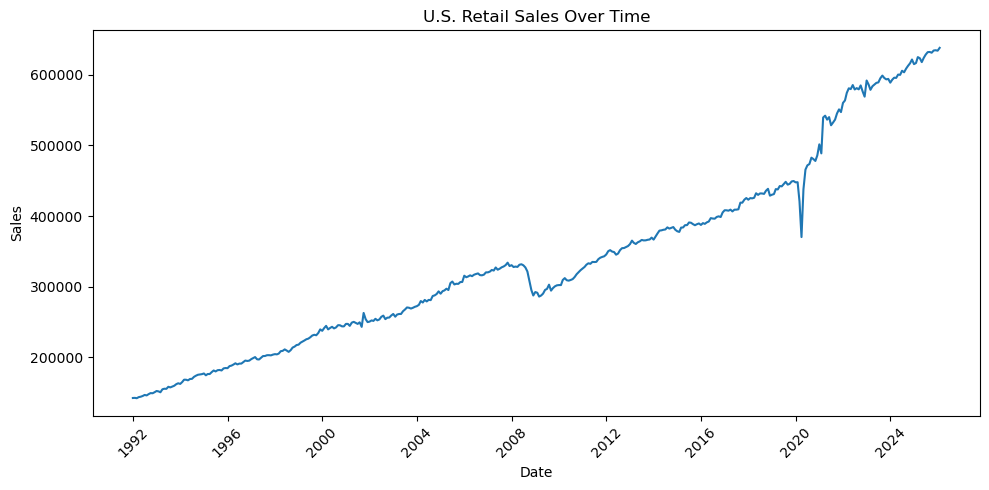

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["date"], df["retail_sales"])
plt.title("U.S. Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# got the retail sales part down now to work on wholesale part

# cant find wholesale data or walmart csv......... -_- data is hard to come by especially with monetary info

# okay found a dataset but lets check if it works 

In [238]:
dfwal = pd.read_csv("Walmart_sales.csv")

dfwal.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## lets try to do the wholesale now. searching for wholesale data found one lets see if it works

In [239]:

# Load the Sam's Club net sales dataset
sams = pd.read_csv("sams_club_net_sales_1991_current.csv")

# Check the first few rows
sams.head()

,walmart_fiscal_year,fiscal_year_end_year,segment,net_sales_millions_usd,net_sales_billions_usd,yoy_change_percent,sales_basis,source_url,notes
0,FY1991,1991,Sam's Club U.S.,6600,6.600,NaN,"Net sales / segment sales, including fuel wher...",https://stock.walmart.com/_assets/_5bb4b0137bc...,Rounded in source as $6.6 billion.
1,FY1992,1992,Sam's Club U.S.,9430,9.430,42.88,"Net sales / segment sales, including fuel wher...",https://www.scribd.com/document/639856979/WalM...,Historical annual-report-derived table; verify...
2,FY1993,1993,Sam's Club U.S.,12339,12.339,30.85,"Net sales / segment sales, including fuel wher...",https://corporate.walmart.com/about/samsclub/s...,Walmart timeline gives rounded $12.3 billion; ...
3,FY1994,1994,Sam's Club U.S.,14749,14.749,19.53,"Net sales / segment sales, including fuel wher...",https://www.scribd.com/document/639856979/WalM...,Historical annual-report-derived table; verify...
4,FY1995,1995,Sam's Club U.S.,18908,18.908,28.20,"Net sales / segment sales, including fuel wher...",https://www.scribd.com/document/639856979/WalM...,Historical annual-report-derived table; verify...


walmart by population  try that


In [240]:
sams.columns

Index(['walmart_fiscal_year', 'fiscal_year_end_year', 'segment',
       'net_sales_millions_usd', 'net_sales_billions_usd',
       'yoy_change_percent', 'sales_basis', 'source_url', 'notes'],
      dtype='str')

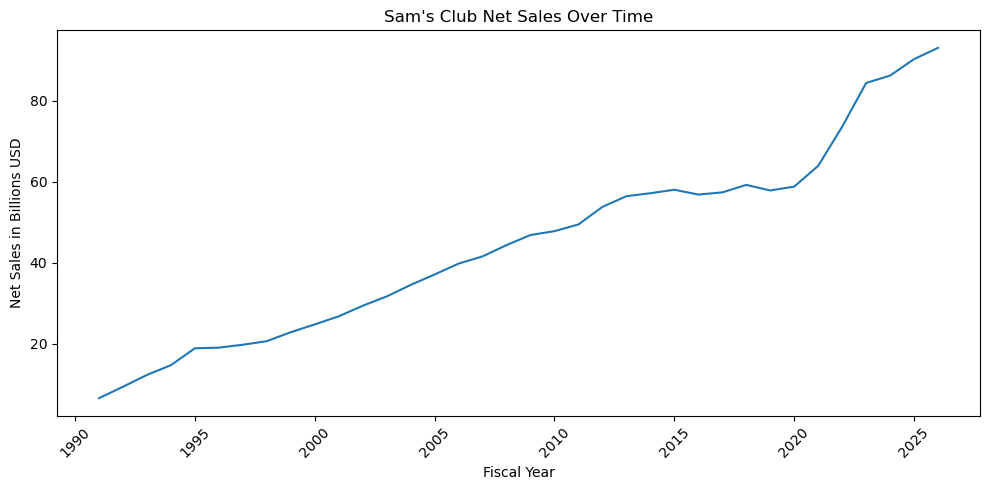

In [241]:



sams = pd.read_csv("sams_club_net_sales_1991_current.csv")

plt.figure(figsize=(10,5))
plt.plot(sams["fiscal_year_end_year"], sams["net_sales_billions_usd"])
plt.title("Sam's Club Net Sales Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Sales in Billions USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

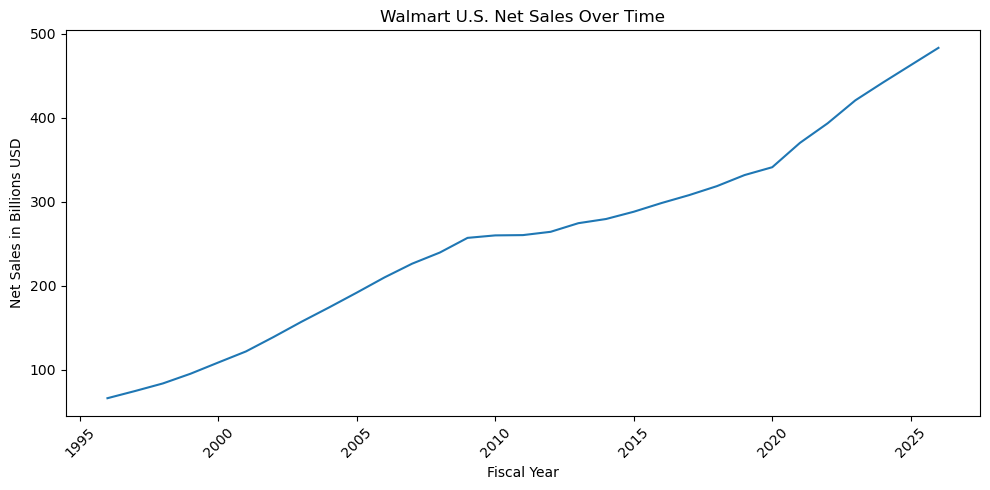

In [242]:
walmart = pd.read_csv("walmart_us_net_sales_1991_current.csv")

# remove blank years
walmart = walmart.dropna(subset=["net_sales_billions_usd"])

plt.figure(figsize=(10,5))
plt.plot(walmart["fiscal_year_end_year"], walmart["net_sales_billions_usd"])

plt.title("Walmart U.S. Net Sales Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Sales in Billions USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

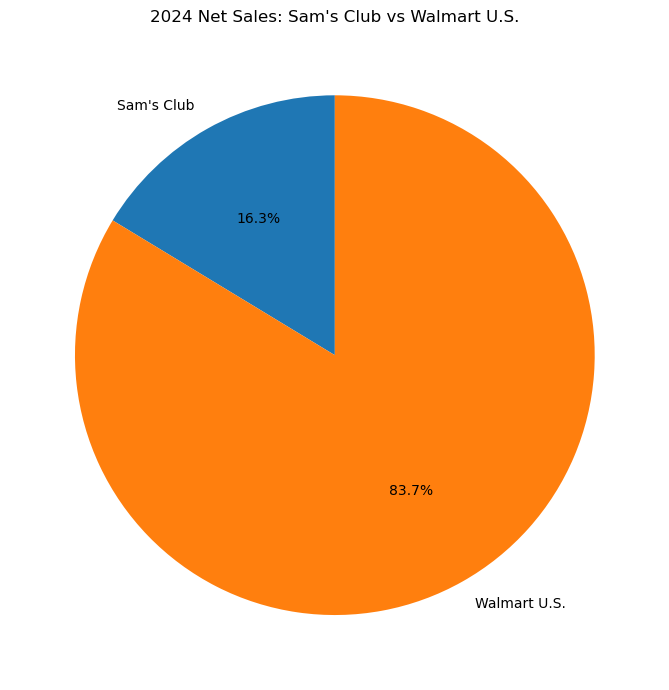

In [243]:
# load both datasets
sams = pd.read_csv("sams_club_net_sales_1991_current.csv")
walmart = pd.read_csv("walmart_us_net_sales_1991_current.csv")

# get 2024 sales
sams_2024 = sams[sams["fiscal_year_end_year"] == 2024]["net_sales_billions_usd"].iloc[0]
walmart_2024 = walmart[walmart["fiscal_year_end_year"] == 2024]["net_sales_billions_usd"].iloc[0]

# create pie chart data
labels = ["Sam's Club", "Walmart U.S."]
sales = [sams_2024, walmart_2024]

plt.figure(figsize=(7,7))
plt.pie(
    sales,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("2024 Net Sales: Sam's Club vs Walmart U.S.")
plt.tight_layout()
plt.show()





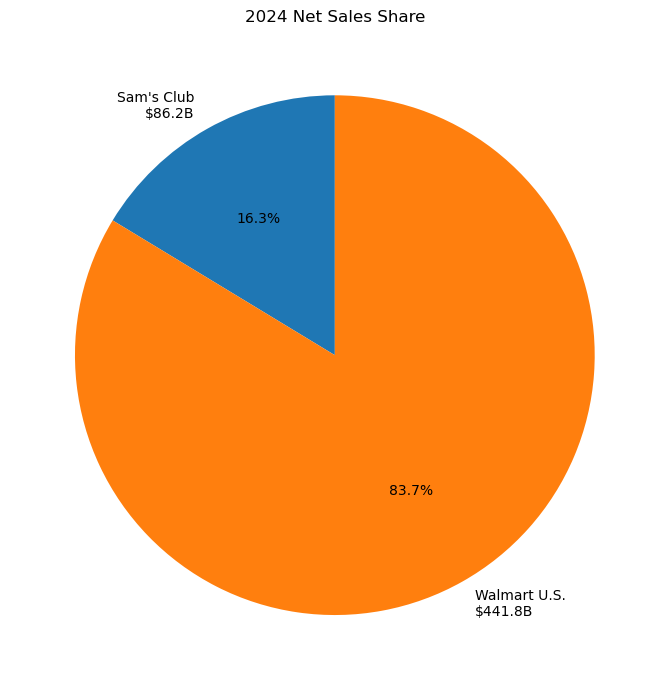

In [244]:


sams = pd.read_csv("sams_club_net_sales_1991_current.csv")
walmart = pd.read_csv("walmart_us_net_sales_1991_current.csv")

sams_2024 = sams[sams["fiscal_year_end_year"] == 2024]["net_sales_billions_usd"].iloc[0]
walmart_2024 = walmart[walmart["fiscal_year_end_year"] == 2024]["net_sales_billions_usd"].iloc[0]

labels = [
    f"Sam's Club\n${sams_2024:.1f}B",
    f"Walmart U.S.\n${walmart_2024:.1f}B"
]

sales = [sams_2024, walmart_2024]

plt.figure(figsize=(7,7))
plt.pie(
    sales,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("2024 Net Sales Share")
plt.tight_layout()
plt.show()

In [245]:
##lets also work on the state map that looked weird

walmart_clean["State"].unique()

<StringArray>
['AR', 'GA', 'MO', 'OK', 'LA', 'KS', 'TN', 'TX', 'MS', 'KY', 'FL', 'VA', 'IL',
 'AL', 'NE', 'SC', 'NC', 'IA', 'IN', 'OH', 'WI', 'CO', 'AZ', 'NM', 'WY', 'WV',
 'MI', 'UT', 'MN', 'SD', 'PA', 'ND', 'CA', 'NV', 'NY', 'MD', 'NH', 'DE', 'NJ',
 'OR', 'ME', 'PR', 'WA', 'MT', 'RI', 'ID', 'CT', 'MA', 'AK', 'DC', 'HI', 'VT']
Length: 52, dtype: str

In [246]:
lat="y"
lon="x"

In [247]:
walmart_clean["State"].sort_values().unique()



<StringArray>
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA',
 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS',
 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
Length: 52, dtype: str

In [248]:
walmart_clean["State"].value_counts().sort_index()

State
AK      9
AL    143
AR    129
AZ    124
CA    303
CO    104
CT     32
DC      2
DE     10
FL    386
GA    210
HI     11
IA     69
ID     27
IL    177
IN    126
KS     82
KY    101
LA    138
MA     48
MD     57
ME     25
MI    117
MN     79
MO    156
MS     86
MT     16
NC    214
ND     17
NE     47
NH     28
NJ     70
NM     53
NV     50
NY    111
OH    170
OK    134
OR     43
PA    159
PR     26
RI      9
SC    122
SD     17
TN    150
TX    590
UT     59
VA    148
VT      6
WA     64
WI     97
WV     44
WY     14
Name: count, dtype: int64

In [249]:
mainland_states = [
    "AL", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA",
    "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA",
    "WV", "WI", "WY"
]

walmart_mainland = walmart_clean[walmart_clean["State"].isin(mainland_states)]

In [250]:
fig = px.scatter_geo(
    walmart_mainland,
    lat="y",
    lon="x",
    hover_name="businessUnit_name",
    hover_data=["City", "State", "Type", "Description"],
    scope="usa",
    title="Walmart Store Locations in the Mainland United States"
)

fig.show()

#need to convert the latitude to something ploTly can read

In [251]:
import pandas as pd
import numpy as np
import plotly.express as px

walmart_clean = pd.read_csv("STORE_STATUS_PUBLIC_VIEW_3007829193429392206.csv")

# make x and y numeric
walmart_clean["x"] = pd.to_numeric(walmart_clean["x"], errors="coerce")
walmart_clean["y"] = pd.to_numeric(walmart_clean["y"], errors="coerce")

# convert x/y map coordinates to longitude/latitude
R = 6378137

walmart_clean["longitude"] = walmart_clean["x"] / R * 180 / np.pi
walmart_clean["latitude"] = (
    2 * np.arctan(np.exp(walmart_clean["y"] / R)) - np.pi / 2
) * 180 / np.pi

In [252]:
fig = px.scatter_geo(
    walmart_clean,
    lat="latitude",
    lon="longitude",
    hover_name="businessUnit_name",
    hover_data=["Address", "City", "State", "Type", "Description"],
    scope="usa",
    title="Walmart Store Locations in the United States"
)

fig.show()

In [253]:


# load dataset
walmart_clean = pd.read_csv("STORE_STATUS_PUBLIC_VIEW_3007829193429392206.csv")

# clean state column
walmart_clean["State"] = walmart_clean["State"].astype(str).str.strip().str.upper()

# make x and y numeric
walmart_clean["x"] = pd.to_numeric(walmart_clean["x"], errors="coerce")
walmart_clean["y"] = pd.to_numeric(walmart_clean["y"], errors="coerce")

# convert x/y map coordinates to longitude and latitude
R = 6378137

walmart_clean["longitude"] = walmart_clean["x"] / R * 180 / np.pi
walmart_clean["latitude"] = (
    2 * np.arctan(np.exp(walmart_clean["y"] / R)) - np.pi / 2
) * 180 / np.pi

# remove missing locations
walmart_clean = walmart_clean.dropna(subset=["latitude", "longitude", "State"])

# get all states/territories in the file
states = sorted(walmart_clean["State"].unique())

fig = go.Figure()

## All locations trace
fig.add_trace(
    go.Scattergeo(
        lat=walmart_clean["latitude"],
        lon=walmart_clean["longitude"],
        mode="markers",
        text=walmart_clean["businessUnit_name"],
        customdata=walmart_clean[["Address", "City", "State", "Type", "Description"]],
        hovertemplate=
            "<b>%{text}</b><br>" +
            "Address: %{customdata[0]}<br>" +
            "City: %{customdata[1]}<br>" +
            "State: %{customdata[2]}<br>" +
            "Type: %{customdata[3]}<br>" +
            "Description: %{customdata[4]}<extra></extra>",
        name="All States",
        marker=dict(size=5)
    )
)

### One trace for each state
for state in states:
    state_data = walmart_clean[walmart_clean["State"] == state]
    
    fig.add_trace(
        go.Scattergeo(
            lat=state_data["latitude"],
            lon=state_data["longitude"],
            mode="markers",
            text=state_data["businessUnit_name"],
            customdata=state_data[["Address", "City", "State", "Type", "Description"]],
            hovertemplate=
                "<b>%{text}</b><br>" +
                "Address: %{customdata[0]}<br>" +
                "City: %{customdata[1]}<br>" +
                "State: %{customdata[2]}<br>" +
                "Type: %{customdata[3]}<br>" +
                "Description: %{customdata[4]}<extra></extra>",
            name=state,
            marker=dict(size=6),
            visible=False
        )
    )

# create dropdown buttons
buttons = []

# button for all states
buttons.append(
    dict(
        label="All States",
        method="update",
        args=[
            {"visible": [True] + [False] * len(states)},
            {"title": "Walmart Store Locations in the United States"}
        ]
    )
)

# buttons for each state
for i, state in enumerate(states):
    visible = [False] * (len(states) + 1)
    visible[i + 1] = True
    
    buttons.append(
        dict(
            label=state,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Walmart Store Locations in {state}"}
            ]
        )
    )

fig.update_layout(
    title="Walmart Store Locations in the United States",
    geo=dict(
        scope="usa",
        showland=True
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.08
        )
    ],
    height=600
)

fig.show()

##now that map looks good 

In [254]:
##walmart by population lets try that
# found a new dataset on us gov website on the population lets upload

pop = pd.read_csv("NST-EST2025-ALLDATA.csv")

pop.columns

##great we have a popestimate 2025 ill use that for the most current data

pop_2025 = pop[pop["SUMLEV"] == 40][["NAME", "POPESTIMATE2025"]]

#40 keeps only state level data if we wanted the whole of united states use 10

# rename columns
pop_2025 = pop_2025.rename(columns={
    "NAME": "state",
    "POPESTIMATE2025": "population_2025"
})




pop_2025.head()



,state,population_2025
14,Alabama,5193088
15,Alaska,737270
16,Arizona,7623818
17,Arkansas,3114791
18,California,39355309


In [255]:
pop_2025.columns

Index(['state', 'population_2025'], dtype='str')

In [256]:
#the states are named we want abbrebiation so we have to abbreviate

state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "Puerto Rico": "PR"
}

In [257]:
pop_2025["State"] = pop_2025["state"].map(state_abbrev)

# we only want the U.S. states + DC, remove Puerto Rico
pop_2025 = pop_2025[pop_2025["State"] != "PR"]

# make the map
fig = px.choropleth(
    pop_2025,
    locations="State",
    locationmode="USA-states",
    color="population_2025",
    scope="usa",
    hover_name="state",
    hover_data={"population_2025": ":,", "State": False},
    labels={"population_2025": "Population"},
    title="2025 Population by State"
)

fig.show()

# not bad shows by state but maybe i want buttons?

In [258]:
fig.update_layout(
    title={
        "text": "2025 Population by State",
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.show()

In [259]:
pop = pd.read_csv("NST-EST2025-ALLDATA.csv")

# keep only state-level rows
pop_2025 = pop[pop["SUMLEV"] == 40][["NAME", "POPESTIMATE2025"]].copy()

# rename columns
pop_2025 = pop_2025.rename(columns={
    "NAME": "state",
    "POPESTIMATE2025": "population_2025"
})

# state abbreviation dictionary
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

# adding state abbreviations
pop_2025["State"] = pop_2025["state"].map(state_abbrev)


# sort states
pop_2025 = pop_2025.sort_values("state")

fig = go.Figure()

# trace for all states
fig.add_trace(
    go.Choropleth(
        locations=pop_2025["State"],
        z=pop_2025["population_2025"],
        locationmode="USA-states",
        text=pop_2025["state"],
        colorbar_title="Population",
        hovertemplate="<b>%{text}</b><br>Population = %{z:,}<extra></extra>",
        visible=True
    )
)

# one trace for each individual state
for _, row in pop_2025.iterrows():
    fig.add_trace(
        go.Choropleth(
            locations=[row["State"]],
            z=[row["population_2025"]],
            locationmode="USA-states",
            text=[row["state"]],
            hovertemplate="<b>%{text}</b><br>Population = %{z:,}<extra></extra>",
            showscale=False,
            visible=False
        )
    )

# dropdown buttons
buttons = []

# all states button
buttons.append(
    dict(
        label="All States",
        method="update",
        args=[
            {"visible": [True] + [False] * len(pop_2025)},
            {"title": "2025 Population by State"}
        ]
    )
)

# individual state buttons
for i, (_, row) in enumerate(pop_2025.iterrows()):
    visible_list = [False] * (len(pop_2025) + 1)
    visible_list[i + 1] = True

    buttons.append(
        dict(
            label=row["state"],
            method="update",
            args=[
                {"visible": visible_list},
                {"title": f"2025 Population in {row['state']}"}
            ]
        )
    )

fig.update_layout(
    title={
        "text": "2025 Population by State",
        "x": 0.5,
        "xanchor": "center"
    },
    geo=dict(
        scope="usa"
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.12
        )
    ]
)

fig.show()

In [260]:
#now lets see the walmart and the number of population in each state

merged = walmart_counts.merge(
    pop_2025[["State", "state", "population_2025"]],
    on="State",
    how="left"
)

merged["stores_per_100k"] = (
    merged["walmart_store_count"] / merged["population_2025"]
) * 100000

merged.head()

,State,walmart_store_count,state,population_2025,stores_per_100k
0,AK,9,Alaska,737270.0,1.220720
1,AL,143,Alabama,5193088.0,2.753660
2,AR,129,Arkansas,3114791.0,4.141530
3,AZ,124,Arizona,7623818.0,1.626482
4,CA,303,California,39355309.0,0.769909


# whoops didnt define the dataframe

In [261]:
walmart_clean ["State"] = walmart_clean["State"].astype(str).str.strip().str.upper()

walmart_counts = (
    walmart_clean
    .groupby("State")
    .size()
    .reset_index(name="walmart_store_count")
)

walmart_counts.head()

,State,walmart_store_count
0,AK,9
1,AL,143
2,AR,129
3,AZ,124
4,CA,303


In [262]:
walmart_population = walmart_counts.merge(
    pop_2025[["State", "state", "population_2025"]],
    on="State",
    how="left"
)

# calculate Walmart stores per 100,000 people
walmart_population["stores_per_100k"] = (
    walmart_population["walmart_store_count"] / walmart_population["population_2025"]
) * 100000

walmart_population.head()

,State,walmart_store_count,state,population_2025,stores_per_100k
0,AK,9,Alaska,737270.0,1.220720
1,AL,143,Alabama,5193088.0,2.753660
2,AR,129,Arkansas,3114791.0,4.141530
3,AZ,124,Arizona,7623818.0,1.626482
4,CA,303,California,39355309.0,0.769909


In [263]:
walmart_population_map = walmart_population[walmart_population["State"] != "PR"]

fig = px.choropleth(
    walmart_population_map,
    locations="State",
    locationmode="USA-states",
    color="walmart_store_count",
    scope="usa",
    hover_name="state",
    hover_data={
        "walmart_store_count": True,
        "population_2025": ":,",
        "stores_per_100k": ":.2f",
        "State": False
    },
    labels={
        "walmart_store_count": "Walmart Stores",
        "population_2025": "Population",
        "stores_per_100k": "Stores per 100k People"
    },
    title="Walmart Stores by State with 2025 Population"
)

fig.update_layout(title_x=0.5)

fig.show()

In [264]:
fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br>" +
    "Walmart Stores = %{z}<br>" +
    "Population = %{customdata[1]:,}<br>" +
    "Stores per 100k People = %{customdata[2]:.2f}" +
    "<extra></extra>"
)

fig.show()

In [265]:
walmart_population_map = walmart_population_map.sort_values("state").reset_index(drop=True)

#lets keep same color scale across all views
zmin = walmart_population_map["walmart_store_count"].min()
zmax = walmart_population_map["walmart_store_count"].max()

fig = go.Figure()

# Trace for all states
fig.add_trace(
    go.Choropleth(
        locations=walmart_population_map["State"],
        z=walmart_population_map["walmart_store_count"],
        locationmode="USA-states",
        text=walmart_population_map["state"],
        customdata=walmart_population_map[["population_2025", "stores_per_100k"]],
        colorscale="Blues",
        zmin=zmin,
        zmax=zmax,
        colorbar_title="Walmart Stores",
        hovertemplate=
            "<b>%{text}</b><br>" +
            "Walmart Stores = %{z}<br>" +
            "Population = %{customdata[0]:,}<br>" +
            "Stores per 100k = %{customdata[1]:.2f}<extra></extra>",
        visible=True
    )
)

# Making   One trace for each state
for _, row in walmart_population_map.iterrows():
    fig.add_trace(
        go.Choropleth(
            locations=[row["State"]],
            z=[row["walmart_store_count"]],
            locationmode="USA-states",
            text=[row["state"]],
            customdata=[[row["population_2025"], row["stores_per_100k"]]],
            colorscale="Blues",
            zmin=zmin,
            zmax=zmax,
            showscale=True,
            hovertemplate=
                "<b>%{text}</b><br>" +
                "Walmart Stores = %{z}<br>" +
                "Population = %{customdata[0]:,}<br>" +
                "Stores per 100k = %{customdata[1]:.2f}<extra></extra>",
            visible=False
        )
    )

# Create dropdown buttons
buttons = []

# bigAll states button
buttons.append(
    dict(
        label="All States",
        method="update",
        args=[
            {"visible": [True] + [False] * len(walmart_population_map)},
            {"title": {"text": "Walmart Stores by State with 2025 Population", "x": 0.5}}
        ]
    )
)

#State buttons
for i, row in walmart_population_map.iterrows():
    visible_list = [False] * (len(walmart_population_map) + 1)
    visible_list[i + 1] = True

    buttons.append(
        dict(
            label=row["state"],
            method="update",
            args=[
                {"visible": visible_list},
                {"title": {"text": f"Walmart Stores in {row['state']}", "x": 0.5}}
            ]
        )
    )

# Updateing layout
fig.update_layout(
    title={"text": "Walmart Stores by State with 2025 Population", "x": 0.5},
    geo=dict(scope="usa"),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.12
        )
    ]
)

fig.show()

# okay this works shows population by state and number of walmart stores this will be a good map to compare to the retail income part 